## FiLM Convolution
This is a sort of CNN context-aware

In [1]:
# %%
# Imports and configuration
import os
import sys
import time
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (balanced_accuracy_score, f1_score, classification_report,
                             confusion_matrix, matthews_corrcoef, brier_score_loss,
                             ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

# --- Project Root Setup ---
def find_project_root(name='Bambino', start=None):
    if start is None:
        start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name:
            return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir:
            return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
if PROJECT_ROOT:
    sys.path.append(PROJECT_ROOT)
    print(f"✅ Added project root: {PROJECT_ROOT}")
else:
    print("❌ Project root not found.")
    sys.exit(1)

from config import settings
import config_film as cfg

# Import Dataset
try:
    from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
except ImportError:
    raise ImportError("Could not import BoaOpenFaceDataset.")

from _utils_ import dataset_utils

# --- Configuration ---
# Using the pre-normalized augmented dataset or the standard normalized dataset
DATASET_TYPE = 'augmented_normalized' # 'normalized' or 'augmented_normalized'
OUT_DIR = Path("./results_FiLM") if DATASET_TYPE == "normalized" else Path("./results_FiLM_augmented")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Training Hyperparameters
TARGET_LEN = cfg.TARGET_LEN          
BATCH_SIZE = cfg.BATCH_SIZE
NUM_EPOCHS = cfg.NUM_EPOCHS
LR = cfg.LR
WEIGHT_DECAY = cfg.WEIGHT_DECAY
PATIENCE = cfg.PATIENCE              
DEVICE = cfg.DEVICE
PRINT_EVERY = cfg.PRINT_EVERY
MODALITIES = cfg.MODALITIES
numeric_features = cfg.numeric_features
cat_features = cfg.cat_features

# %% --- Helpers ---
def ds_to_numpy_and_meta(ds, modalities=MODALITIES, target_len=TARGET_LEN):
    """
    Convert BoaOpenFaceDataset -> (X_ts [N,C,L], meta_df)
    """
    modality_map = {'g': 'gaze_info', 'h': 'head_info', 'f': 'face_info'}
    X_list, metas = [], []
    
    for inst in ds.instances:
        mats = []
        for m in modalities:
            attr = modality_map[m]
            mat = getattr(inst, attr)
            mats.append(np.asarray(mat))
        
        X = np.concatenate(mats, axis=1)  # [L, D_tot]
        L = X.shape[0]
        
        # Pad/Truncate
        if L >= target_len:
            start = (L - target_len) // 2
            X_t = X[start:start+target_len, :]
        else:
            pad = np.zeros((target_len - L, X.shape[1]), dtype=X.dtype)
            X_t = np.vstack([X, pad])
            
        X_list.append(X_t.T)  # [C, L]
        
        # Metadata
        age = float(inst.age) if inst.age is not None else np.nan
        meta_row = {
            'pt_id': inst.pt_id,
            'trial_id': inst.trial_id,
            'label': int(inst.trial_type),
            'age': age,
            'sex': inst.sex if hasattr(inst, 'sex') else np.nan,
            'duration_s': L / getattr(ds, "FRAME_RATE", 25)
        }
        metas.append(meta_row)
        
    X_arr = np.stack(X_list, axis=0).astype(np.float32)
    meta_df = pd.DataFrame(metas)
    return X_arr, meta_df


✅ Added project root: /home/phd2/Scrivania/CorsoRepo/Bambino


In [2]:
# %% --- Load Data ---
print("\n📂 Loading datasets...")

TRAIN_PATH = settings.get_dataset_path(DATASET_TYPE, settings.training_filename)
VAL_PATH = settings.get_dataset_path(DATASET_TYPE, settings.validation_filename)
TEST_PATH = settings.get_dataset_path(DATASET_TYPE, settings.test_filename)

train_ds = BoaOpenFaceDataset.load_dataset(TRAIN_PATH)
val_ds   = BoaOpenFaceDataset.load_dataset(VAL_PATH)
test_ds  = BoaOpenFaceDataset.load_dataset(TEST_PATH)

print(f"Instances: Train {len(train_ds)}, Val {len(val_ds)}, Test {len(test_ds)}")

# Convert to Numpy
X_train_ts, df_train_meta = ds_to_numpy_and_meta(train_ds)
X_val_ts,   df_val_meta   = ds_to_numpy_and_meta(val_ds)
X_test_ts,  df_test_meta  = ds_to_numpy_and_meta(test_ds)

y_train = df_train_meta['label'].values
y_val   = df_val_meta['label'].values
y_test  = df_test_meta['label'].values

# Process Metadata
print("   Processing Metadata...")
meta_preproc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='drop'
)

X_meta_train = meta_preproc.fit_transform(df_train_meta[numeric_features + cat_features])
X_meta_val   = meta_preproc.transform(df_val_meta[numeric_features + cat_features])
X_meta_test  = meta_preproc.transform(df_test_meta[numeric_features + cat_features])


# %% --- PyTorch Setup ---
def build_loader(X_ts, X_meta, y, batch_size=BATCH_SIZE, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X_ts, dtype=torch.float32),
        torch.tensor(X_meta, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    # n_workers > 0 helps if you have RAM, set to 0 if it crashes
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = build_loader(X_train_ts, X_meta_train, y_train, shuffle=True)
val_loader   = build_loader(X_val_ts, X_meta_val, y_val, shuffle=False)
test_loader  = build_loader(X_test_ts, X_meta_test, y_test, shuffle=False)

# %% --- FiLM Model Definition ---
class ConvFiLM(nn.Module):
    def __init__(self, in_channels, meta_dim, channels=(8, 16), kernel_size=3, dropout=0.6, head_dim=16): # Reduced head_dim
        super().__init__()
        
        # CNN Backbone (Tiny)
        self.conv1 = nn.Conv1d(in_channels, channels[0], kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(channels[0])
        
        self.conv2 = nn.Conv1d(channels[0], channels[1], kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(channels[1])
        
        # FiLM Generators (Bottlenecked)
        # Force the model to compress metadata info before modulating
        self.film1 = nn.Sequential(
            nn.Linear(meta_dim, 8), # Bottleneck
            nn.ReLU(),
            nn.Linear(8, channels[0] * 2)
        )
        self.film2 = nn.Sequential(
            nn.Linear(meta_dim, 8), # Bottleneck
            nn.ReLU(),
            nn.Linear(8, channels[1] * 2)
        )
        
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        # Classification Head (Simpler)
        head_in = channels[1] + meta_dim
        self.head = nn.Sequential(
            nn.Linear(head_in, head_dim), # Smaller hidden layer
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_dim, 1)
        )
        
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv1d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            
        # FiLM Init (Identity)
        if hasattr(self, 'film1'):
            nn.init.normal_(self.film1[-1].weight, 0, 0.01) # Target the last linear layer
            nn.init.constant_(self.film1[-1].bias, 0)
            self.film1[-1].bias.data[:self.film1[-1].out_features//2].fill_(1.0)

    def forward(self, x, meta):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        
        # Apply FiLM 1
        params1 = self.film1(meta)
        gamma1, beta1 = params1.chunk(2, dim=1)
        x = x * gamma1.unsqueeze(-1) + beta1.unsqueeze(-1)
        
        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        
        # Apply FiLM 2
        params2 = self.film2(meta)
        gamma2, beta2 = params2.chunk(2, dim=1)
        x = x * gamma2.unsqueeze(-1) + beta2.unsqueeze(-1)
        
        # Pool & Head
        x = self.pool(x).squeeze(-1)
        x_cat = torch.cat([x, meta], dim=1)
        return self.head(x_cat).squeeze(-1)

# Initialize Model
model = ConvFiLM(
    in_channels=X_train_ts.shape[1], 
    meta_dim=X_meta_train.shape[1],
    channels=getattr(cfg, 'channels', (8, 16) ),    
    kernel_size=getattr(cfg, 'kernel_size', 3),
    dropout=getattr(cfg, 'dropout', 0.6),
    head_dim=getattr(cfg, 'head_dim', 32)
).to(DEVICE)

print(f"\n🧠 Model Initialized on {DEVICE}")



📂 Loading datasets...
Instances: Train 1970, Val 140, Test 137
   Processing Metadata...

🧠 Model Initialized on cuda


In [3]:
# %% --- Training Loop with OneCycleLR ---
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05) # Increased WD

# OneCycle Scheduler: Helps convergence on small data
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=3e-3, 
    steps_per_epoch=len(train_loader), 
    epochs=NUM_EPOCHS
)

best_val_score = -1.0
best_model_state = None
epochs_no_improve = 0

print(f"\n🚀 Starting Training for {NUM_EPOCHS} epochs (OneCycle)...")

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    
    for xb, xm, yb in train_loader:
        xb, xm, yb = xb.to(DEVICE), xm.to(DEVICE), yb.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(xb, xm)
        loss = criterion(logits, yb)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step() # Step every batch for OneCycle
        train_loss += loss.item()
        
    train_loss /= len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for xb, xm, yb in val_loader:
            xb, xm, yb = xb.to(DEVICE), xm.to(DEVICE), yb.to(DEVICE)
            logits = model(xb, xm)
            loss = criterion(logits, yb)
            val_loss += loss.item()
            
            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(yb.cpu().numpy())
            
    val_loss /= len(val_loader)
    
    # Validation Metrics
    preds_arr = np.array(all_preds)
    labels_arr = np.array(all_labels)
    
    best_thr = 0.5
    best_bal = 0.0
    for thr in np.linspace(0.3, 0.7, 20): # Narrow search range
        p = (preds_arr >= thr).astype(int)
        bal = balanced_accuracy_score(labels_arr, p)
        if bal > best_bal:
            best_bal = bal
            best_thr = thr
            
    # Save Best Model
    if best_bal > best_val_score:
        best_val_score = best_bal
        best_model_state = model.state_dict()
        epochs_no_improve = 0
        print("  <-- New Best")
    else:
        epochs_no_improve += 1
        
    if epoch % PRINT_EVERY == 0:
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val BalAcc: {best_bal:.4f}")
        
    if epochs_no_improve >= PATIENCE:
        print(f"⏹️ Early stopping at epoch {epoch}")
        break


🚀 Starting Training for 40 epochs (OneCycle)...
  <-- New Best
Epoch 01 | Train Loss: 0.7172 | Val Loss: 0.7275 | Val BalAcc: 0.5625
  <-- New Best
Epoch 02 | Train Loss: 0.7139 | Val Loss: 0.6962 | Val BalAcc: 0.5714
  <-- New Best
Epoch 03 | Train Loss: 0.7062 | Val Loss: 0.6830 | Val BalAcc: 0.5893
  <-- New Best
Epoch 04 | Train Loss: 0.6963 | Val Loss: 0.6829 | Val BalAcc: 0.6161
  <-- New Best
Epoch 05 | Train Loss: 0.6924 | Val Loss: 0.6422 | Val BalAcc: 0.6786
Epoch 06 | Train Loss: 0.6762 | Val Loss: 0.6188 | Val BalAcc: 0.6562
Epoch 07 | Train Loss: 0.6165 | Val Loss: 0.5391 | Val BalAcc: 0.5580
  <-- New Best
Epoch 08 | Train Loss: 0.5539 | Val Loss: 0.6426 | Val BalAcc: 0.7054
Epoch 09 | Train Loss: 0.5013 | Val Loss: 0.6205 | Val BalAcc: 0.6161
Epoch 10 | Train Loss: 0.5061 | Val Loss: 0.6352 | Val BalAcc: 0.6741
Epoch 11 | Train Loss: 0.4836 | Val Loss: 0.8276 | Val BalAcc: 0.6562
Epoch 12 | Train Loss: 0.4579 | Val Loss: 0.7315 | Val BalAcc: 0.6562
Epoch 13 | Train Loss


📝 Evaluating on Test Set...

TEST Balanced Accuracy: 0.4971
TEST MCC: -0.0058

Classification Report:
              precision    recall  f1-score   support

         0.0     0.1923    0.1852    0.1887        27
         1.0     0.8018    0.8091    0.8054       110

    accuracy                         0.6861       137
   macro avg     0.4971    0.4971    0.4971       137
weighted avg     0.6817    0.6861    0.6839       137



<Figure size 600x500 with 0 Axes>

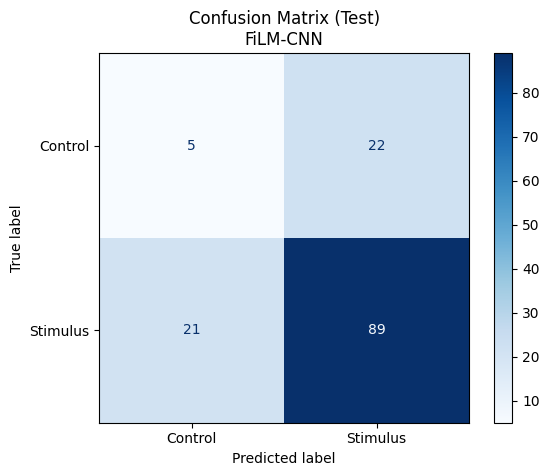

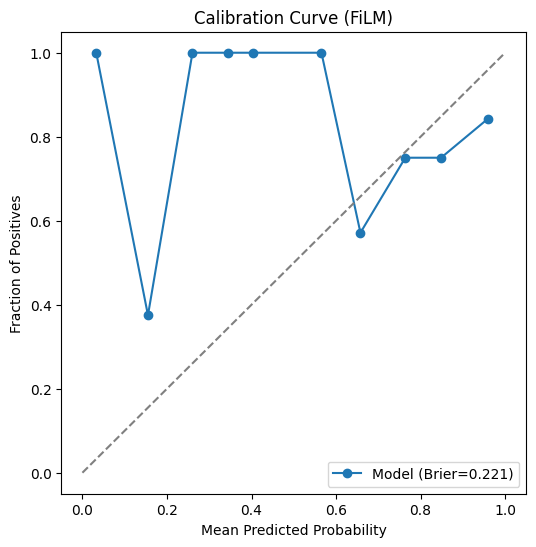


👶 Per-Baby Performance Analysis...

Per-Baby Balanced Accuracy and F1 Scores (Test):
------------------------------------------------------------
BabyID: bam1_008   | Age: 6.70  | Sex: F   | Balanced Acc: 0.4000       | F1 Score: 0.8000
BabyID: bam1_018   | Age: 4.96  | Sex: M   | Balanced Acc: 0.4062       | F1 Score: 0.7879
BabyID: bam1_044   | Age: 6.08  | Sex: M   | Balanced Acc: 0.4375       | F1 Score: 0.6897
BabyID: bam1_005   | Age: 5.42  | Sex: F   | Balanced Acc: 0.5312       | F1 Score: 0.8125
BabyID: bam1_020   | Age: 4.83  | Sex: F   | Balanced Acc: 0.5312       | F1 Score: 0.8125
BabyID: bam1_026   | Age: 6.54  | Sex: F   | Balanced Acc: 0.5312       | F1 Score: 0.8125
BabyID: bam1_024   | Age: 6.41  | Sex: F   | Balanced Acc: 0.6250       | F1 Score: 0.9091
------------------------------------------------------------


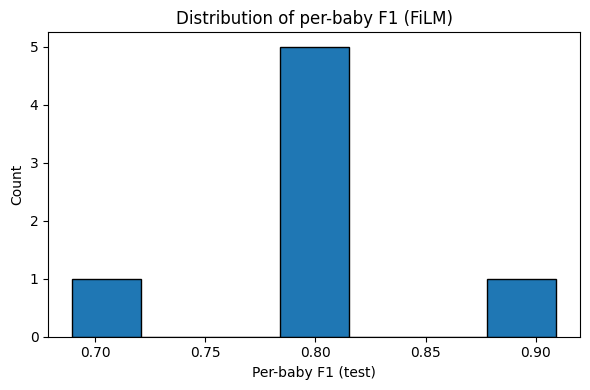

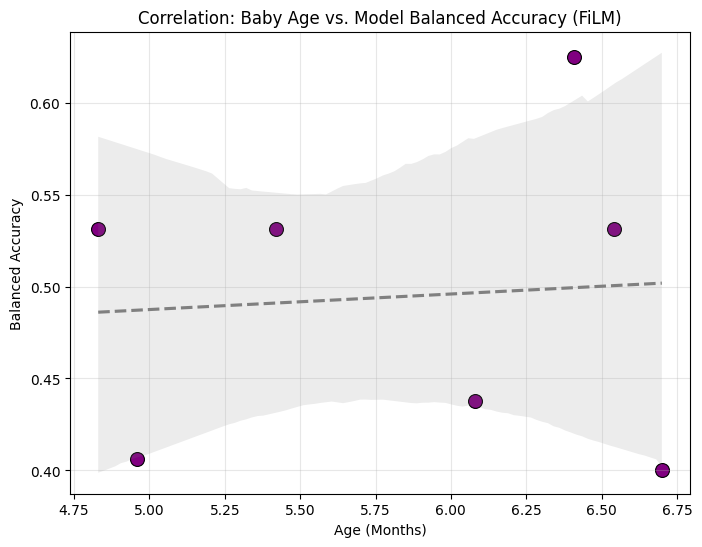


✅ Analysis Complete. Results saved to results_FiLM_augmented


In [4]:
# %% --- Evaluation ---
print("\n📝 Evaluating on Test Set...")
model.load_state_dict(best_model_state)
model.eval()

test_probs, test_labels = [], []
with torch.no_grad():
    for xb, xm, yb in test_loader:
        xb, xm = xb.to(DEVICE), xm.to(DEVICE)
        logits = model(xb, xm)
        test_probs.extend(torch.sigmoid(logits).cpu().numpy())
        test_labels.extend(yb.numpy())

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)

# Final Metrics
y_pred_test = (test_probs >= best_thr).astype(int)
bal_test = balanced_accuracy_score(test_labels, y_pred_test)
mcc_test = matthews_corrcoef(test_labels, y_pred_test)
brier_test = brier_score_loss(test_labels, test_probs)

print(f"\nTEST Balanced Accuracy: {bal_test:.4f}")
print(f"TEST MCC: {mcc_test:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, y_pred_test, digits=4))

# Save Text Report
with open(OUT_DIR / "film_classification_report_test.txt", "w") as f:
    f.write(classification_report(test_labels, y_pred_test, digits=4))

# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred_test)
plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Stimulus"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Test)\nFiLM-CNN")
plt.savefig(OUT_DIR / "film_confusion_matrix_test.png")
plt.show()

# Calibration Curve
frac_pos, mean_pred = calibration_curve(test_labels, test_probs, n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(mean_pred, frac_pos, marker='o', label=f'Model (Brier={brier_test:.3f})')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (FiLM)')
plt.legend()
plt.savefig(OUT_DIR / "film_calibration_curve_test.png")
plt.show()

# %% --- Detailed Per-Baby Analysis ---
print("\n👶 Per-Baby Performance Analysis...")

pt_ids = df_test_meta['pt_id'].unique()
per_baby_details = []
per_baby_f1_list = []

# Use metadata directly to map back (order preserved)
df_test_meta['pred_prob'] = test_probs
df_test_meta['pred_label'] = y_pred_test
df_test_meta['true_label'] = test_labels

for pid in pt_ids:
    sub = df_test_meta[df_test_meta['pt_id'] == pid]
    if len(sub) < 2: continue
    
    # calculate F1 and balanced accuracy for each baby
    bal_acc = balanced_accuracy_score(sub['true_label'], sub['pred_label'])
    f1 = f1_score(sub['true_label'], sub['pred_label'], zero_division=0)
    
    age = sub['age'].iloc[0]
    sex_val = sub['sex'].iloc[0]
    sex_str = "F" if str(sex_val) == "0" else "M" if str(sex_val) == "1" else str(sex_val)
    
    per_baby_details.append((pid, age, sex_str, bal_acc, f1))
    per_baby_f1_list.append(f1)

# 1. Print Inline List (Sorted by Balanced Accuracy)
per_baby_details.sort(key=lambda x: x[3])
print("\nPer-Baby Balanced Accuracy and F1 Scores (Test):")
print("-" * 60)
for pid, age, sex, bal_acc, f1 in per_baby_details:
    print(f"BabyID: {pid:<10} | Age: {age:<5.2f} | Sex: {sex:<3} | Balanced Acc: {bal_acc:<12.4f} | F1 Score: {f1:.4f}")
print("-" * 60)

# 2. Histogram (Matching previous models)
if per_baby_f1_list:
    plt.figure(figsize=(6,4))
    plt.hist(per_baby_f1_list, bins=min(20, len(per_baby_f1_list)), edgecolor='black')
    plt.xlabel('Per-baby F1 (test)')
    plt.ylabel('Count')
    plt.title('Distribution of per-baby F1 (FiLM)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'film_per_baby_f1_hist.png')
    plt.show()

# 3. Scatter Plot: Age vs Balanced Accuracy
ages = [x[1] for x in per_baby_details]
bal_accs = [x[3] for x in per_baby_details]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=ages, y=bal_accs, s=100, color='purple', edgecolor='black')
# Add trendline
sns.regplot(x=ages, y=bal_accs, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title("Correlation: Baby Age vs. Model Balanced Accuracy (FiLM)")
plt.xlabel("Age (Months)")
plt.ylabel("Balanced Accuracy")
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR / "film_age_vs_balanced_accuracy_scatter.png")
plt.show()

print("\n✅ Analysis Complete. Results saved to", OUT_DIR)

## Bootstrap

>>> Step 5: Bootstrap Analysis on Test Set (FiLM-CNN)
Generating predictions for FiLM_CNN on full test set...
Starting bootstrap (n=200) for FiLM_CNN (Augmented: No)...
  Bootstrap iteration 20/200...
  Bootstrap iteration 40/200...
  Bootstrap iteration 60/200...
  Bootstrap iteration 80/200...
  Bootstrap iteration 100/200...
  Bootstrap iteration 120/200...
  Bootstrap iteration 140/200...
  Bootstrap iteration 160/200...
  Bootstrap iteration 180/200...
  Bootstrap iteration 200/200...
Bootstrap runs used: 200/200
Balanced Acc: mean=0.5022, 95% CI=(0.4128, 0.6026)
F1 Score:     mean=0.8073, 95% CI=(0.7367, 0.8608)
AUC:          mean=0.5357, 95% CI=(0.3539, 0.6627)
Specificity:  mean=0.1950, 95% CI=(0.0476, 0.3756)
Appending new result.
Comparison results saved to /home/phd2/Scrivania/CorsoRepo/Bambino/paper_results/performance_comparison/performance_comparison.csv


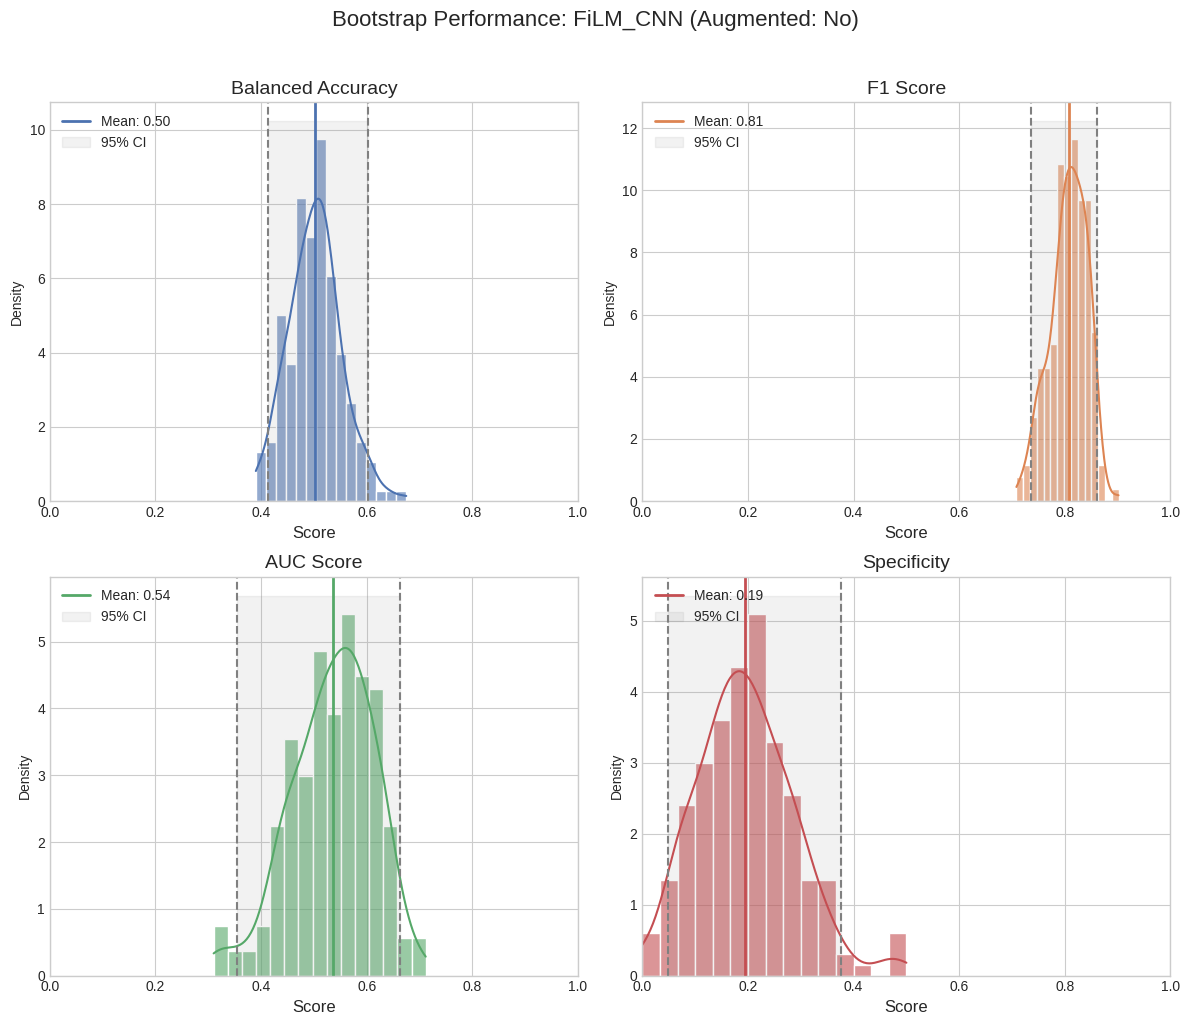

In [5]:
# %% --- 5. Bootstrap Analysis ---
print(">>> Step 5: Bootstrap Analysis on Test Set (FiLM-CNN)")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
MODEL_NAME = "FiLM_CNN"
IS_AUGMENTED = "Yes" if "augmented" in cfg.dataset_type else "No"
RESULTS_CSV_PATH = Path("/home/phd2/Scrivania/CorsoRepo/Bambino/paper_results/performance_comparison/performance_comparison.csv")
OUTPUT_DIR = Path("./results_FiLM") if cfg.dataset_type == "normalized" else Path("./results_FiLM_augmented")

# Parameters
n_boot = 200
frac = 0.70
N_test = len(y_test)
boot_size = max(1, int(round(frac * N_test)))

# --- PRE-CALCULATE PREDICTIONS ---
# We run inference once on the full test set to avoid re-running the NN 200 times.
# Assumes 'model' and 'best_thr' exist from previous steps. 
# If best_thr is not defined, default to 0.5.

if 'best_thr' not in locals():
    print("Warning: 'best_thr' not found. Defaulting to 0.5")
    best_thr = 0.5

print(f"Generating predictions for {MODEL_NAME} on full test set...")
model.eval()
y_probs_all = []
y_true_all = []

with torch.no_grad():
    for X_ts_batch, X_meta_batch, y_batch in test_loader:
        X_ts_batch, X_meta_batch = X_ts_batch.to(DEVICE), X_meta_batch.to(DEVICE)
        
        # FiLM Forward pass (requires both time series and metadata)
        outputs = model(X_ts_batch, X_meta_batch)
        
        # Apply Sigmoid to get probabilities
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        
        y_probs_all.extend(probs)
        y_true_all.extend(y_batch.numpy().flatten())

y_probs_all = np.array(y_probs_all)
y_true_all = np.array(y_true_all)

# --- BOOTSTRAP LOOP ---
rng = np.random.default_rng(42)
boot_bal_acc = []
boot_f1 = []
boot_auc = []
boot_specificity = []

print(f"Starting bootstrap (n={n_boot}) for {MODEL_NAME} (Augmented: {IS_AUGMENTED})...")

for i in range(n_boot):
    # Progress update every n_boot/10 iterations
    if (i+1) % (n_boot // 10) == 0:
        print(f"  Bootstrap iteration {i+1}/{n_boot}...")

    # Bootstrap indices
    idx = rng.choice(N_test, size=boot_size, replace=True)
    
    # Resample from pre-calculated predictions and labels
    pb = y_probs_all[idx]
    yb = y_true_all[idx]

    # Guard: need at least 2 classes for ROC AUC usually
    if len(np.unique(yb)) < 2:
        continue

    # Calculate Metrics
    try:
        yhat = (pb >= best_thr).astype(int)
        
        # Metrics
        boot_bal_acc.append(balanced_accuracy_score(yb, yhat))
        boot_f1.append(f1_score(yb, yhat, zero_division=0))
        boot_auc.append(roc_auc_score(yb, pb))
        
        # Specificity Calculation (TN / (TN + FP))
        cm = confusion_matrix(yb, yhat)
        # Handle cases where confusion matrix might not be 2x2 (e.g. only 1 class predicted)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        else:
            # Fallback if only one class is present/predicted (edge case in small bootstraps)
            # If true labels are all 0, and we predict all 0 -> spec = 1.0
            # If true labels are all 1, specificity is undefined (or N/A), treat as nan or skip
            spec = np.nan 
        
        if not np.isnan(spec):
            boot_specificity.append(spec)
            
    except ValueError:
        continue

boot_res = pd.DataFrame({
    "balanced_accuracy": boot_bal_acc, 
    "f1": boot_f1, 
    "auc": boot_auc,
    "spec": boot_specificity
})

# Save Bootstrap raw results
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
boot_res.to_csv(OUTPUT_DIR / "bootstrap_test_metrics.csv", index=False)

# --- CI Calculation ---
def _ci(x, alpha=0.05):
    # Filter NaNs if any specificities failed
    x = np.array(x)
    x = x[~np.isnan(x)]
    if len(x) == 0: return np.nan, np.nan
    lo, hi = np.percentile(x, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)

bal_mean = boot_res["balanced_accuracy"].mean()
bal_ci = _ci(boot_res["balanced_accuracy"])

f1_mean = boot_res["f1"].mean()
f1_ci = _ci(boot_res["f1"])

auc_mean = boot_res["auc"].mean()
auc_ci = _ci(boot_res["auc"])

spec_mean = boot_res["spec"].mean()
spec_ci = _ci(boot_res["spec"])

print(f"Bootstrap runs used: {len(boot_res)}/{n_boot}")
print(f"Balanced Acc: mean={bal_mean:.4f}, 95% CI=({bal_ci[0]:.4f}, {bal_ci[1]:.4f})")
print(f"F1 Score:     mean={f1_mean:.4f}, 95% CI=({f1_ci[0]:.4f}, {f1_ci[1]:.4f})")
print(f"AUC:          mean={auc_mean:.4f}, 95% CI=({auc_ci[0]:.4f}, {auc_ci[1]:.4f})")
print(f"Specificity:  mean={spec_mean:.4f}, 95% CI=({spec_ci[0]:.4f}, {spec_ci[1]:.4f})")

# --- SAVE TO COMPARISON CSV ---
new_row = {
    "model": MODEL_NAME,
    "augmented": IS_AUGMENTED,
    "bal_acc_mean": round(bal_mean, 4),
    "bal_acc_ci_low": round(bal_ci[0], 4),
    "bal_acc_ci_high": round(bal_ci[1], 4),
    "auc_mean": round(auc_mean, 4),
    "auc_ci_low": round(auc_ci[0], 4),
    "auc_ci_high": round(auc_ci[1], 4),
    "f1_mean": round(f1_mean, 4),
    "f1_ci_low": round(f1_ci[0], 4),
    "f1_ci_high": round(f1_ci[1], 4),
    "spec_mean": round(spec_mean, 4),
    "spec_ci_low": round(spec_ci[0], 4),
    "spec_ci_high": round(spec_ci[1], 4)
}

RESULTS_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

if RESULTS_CSV_PATH.exists():
    df_results = pd.read_csv(RESULTS_CSV_PATH)
    # Check if 'spec_mean' column exists, if not create it
    if "spec_mean" not in df_results.columns:
        df_results["spec_mean"] = np.nan
        df_results["spec_ci_low"] = np.nan
        df_results["spec_ci_high"] = np.nan
        
    mask = (df_results["model"] == MODEL_NAME) & (df_results["augmented"] == IS_AUGMENTED)
    if mask.any():
        print(f"Entry for {MODEL_NAME} (Augmented: {IS_AUGMENTED}) exists. Updating row.")
        for col, val in new_row.items():
            df_results.loc[mask, col] = val
    else:
        print(f"Appending new result.")
        df_results = pd.concat([df_results, pd.DataFrame([new_row])], ignore_index=True)
else:
    print(f"Creating new results file.")
    df_results = pd.DataFrame([new_row])

df_results.to_csv(RESULTS_CSV_PATH, index=False)
print(f"Comparison results saved to {RESULTS_CSV_PATH}")

# --- PLOTTING ---
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52'] # Added 4th color
metrics_list = [
    ("balanced_accuracy", "Balanced Accuracy", bal_mean, bal_ci, colors[0]),
    ("f1", "F1 Score", f1_mean, f1_ci, colors[1]),
    ("auc", "AUC Score", auc_mean, auc_ci, colors[2]),
    ("spec", "Specificity", spec_mean, spec_ci, colors[3])
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
fig.suptitle(f"Bootstrap Performance: {MODEL_NAME} (Augmented: {IS_AUGMENTED})", fontsize=16, y=1.02)

for ax, (col, title, mean_val, ci_val, color) in zip(axes, metrics_list):
    data = boot_res[col].dropna() # Ensure no NaNs in plot
    sns.histplot(data, bins=15, kde=True, ax=ax, color=color, edgecolor='white', alpha=0.6, stat="density")
    ax.axvline(mean_val, color=color, linestyle='-', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(ci_val[0], color='gray', linestyle='--', linewidth=1.5)
    ax.axvline(ci_val[1], color='gray', linestyle='--', linewidth=1.5)
    ymin, ymax = ax.get_ylim()
    ax.fill_betweenx([ymin, ymax], ci_val[0], ci_val[1], color='gray', alpha=0.1, label='95% CI')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Score", fontsize=12)
    ax.set_xlim(0, 1)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bootstrap_test_distributions.png", dpi=300, bbox_inches="tight")
plt.show()